In [33]:
import numpy as np 
import pandas as pd 
import time

import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")

# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")
# Set default color palette
sns.set_palette("husl")


pd.set_option('display.max_columns', None)


print("libraries Successfully imported")

libraries Successfully imported


In [34]:
data = pd.read_csv("day.csv")
df = pd.DataFrame(data)
df.head()



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [35]:
print("Dataset Information")
print("-" * 50)
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    str    
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.4 KB


In [36]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

print(f"There are {len(numeric_cols)} Numerical columns")
print(numeric_cols)
print("")
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"There are {len(categorical_cols)} Categorical columns")
print(categorical_cols)

There are 15 Numerical columns
Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='str')

There are 1 Categorical columns
Index(['dteday'], dtype='str')


In [37]:
"""Task 4
Generate descriptive statistics."""

print("Statistical Summary")
print("-" * 50)
df.describe()

Statistical Summary
--------------------------------------------------


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


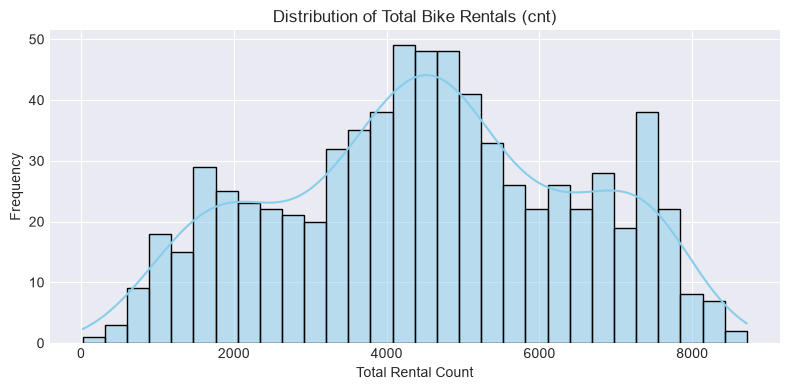

In [38]:
# 1. Distribution of Target Variable (cnt)
plt.figure(figsize=(8, 4))
sns.histplot(df['cnt'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Total Bike Rentals (cnt)')
plt.xlabel('Total Rental Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('cnt_distribution.png')
plt.show()
plt.close()

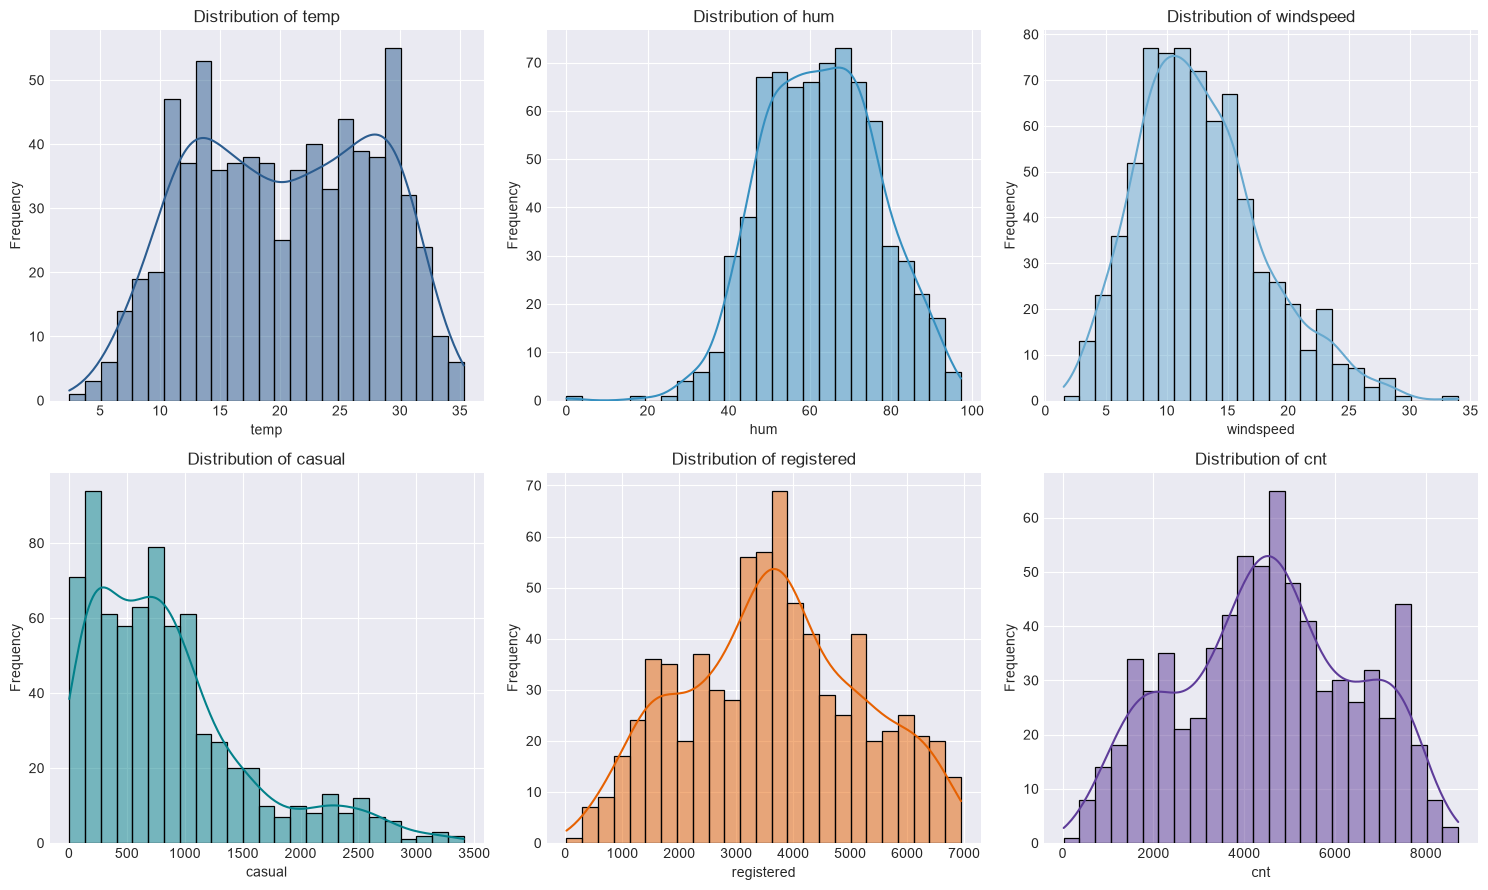

In [39]:
# 2. Distribution Plots (Histograms with KDE)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
num_vars = ['temp', 'hum', 'windspeed', 'casual','registered', 'cnt']
colors = ['#2b5c8f', '#3690c0', '#67a9cf', '#02818a', '#e66101', '#5e3c99']

for i, var in enumerate(num_vars):
    row, col = divmod(i, 3)
    sns.histplot(df[var], kde=True, ax=axes[row, col], color=colors[i], bins=25)
    axes[row, col].set_title(f'Distribution of {var}')
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=300)
plt.show()
plt.close()

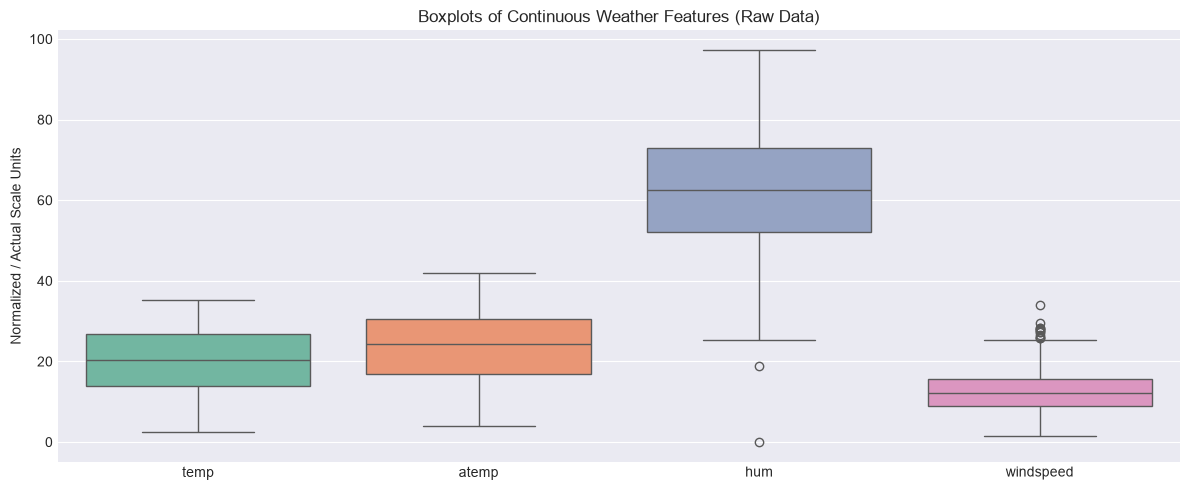

In [40]:
# 3. Boxplots for Outlier Analysis across Continuous Features
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df[['temp', 'atemp', 'hum', 'windspeed']], palette='Set2', ax=ax)
ax.set_title('Boxplots of Continuous Weather Features (Raw Data)')
ax.set_ylabel('Normalized / Actual Scale Units')
plt.tight_layout()
plt.savefig('eda_boxplots_weather.png', dpi=300)
plt.show()
plt.close()

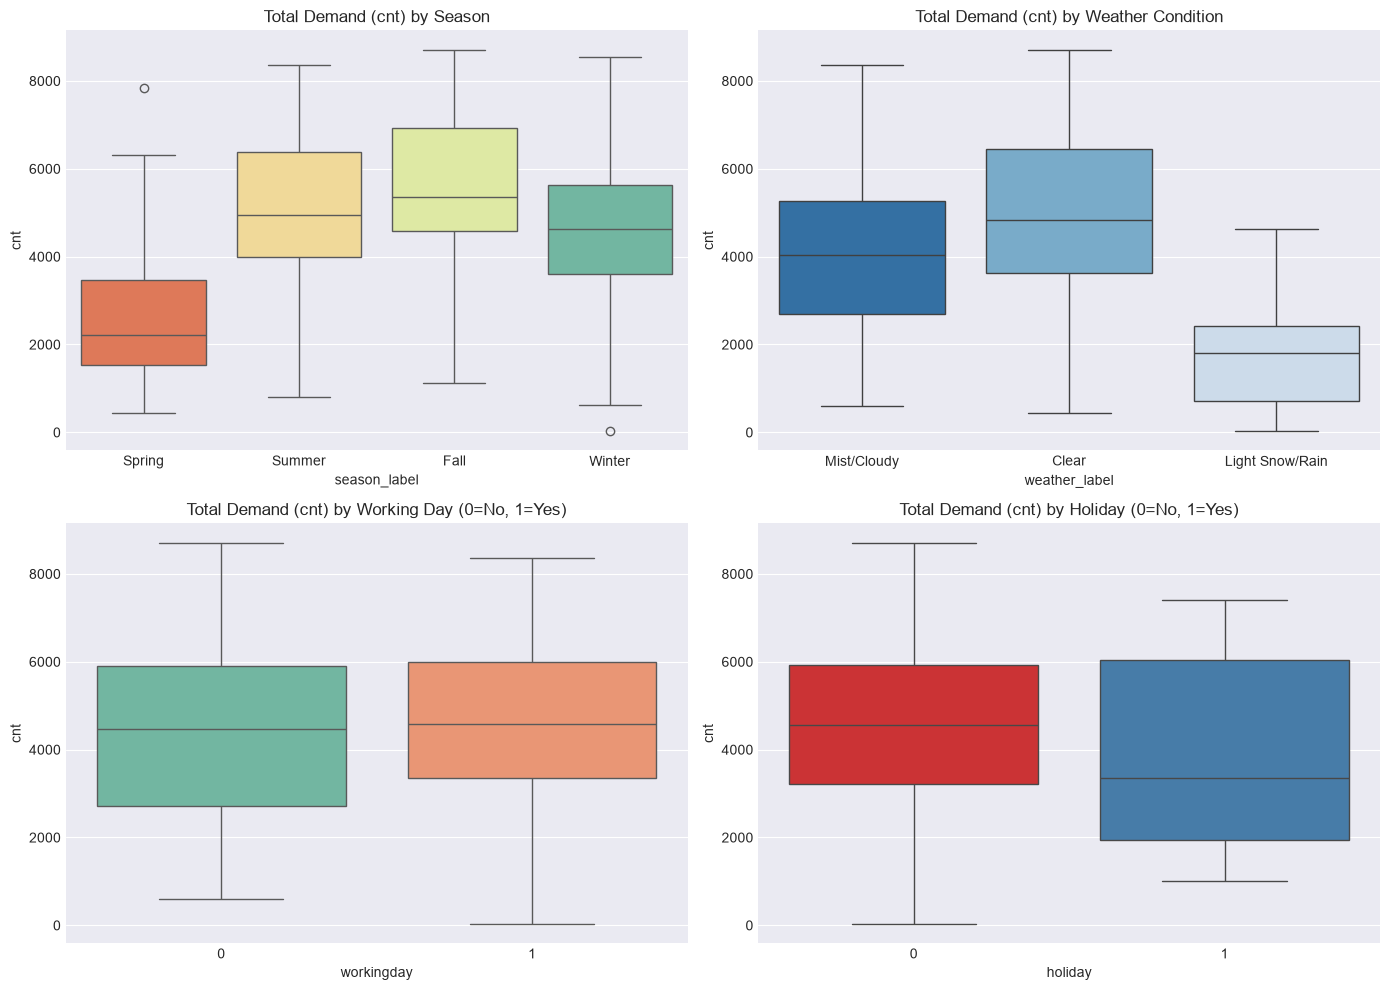

In [41]:
# 4. Boxplots for Target (cnt) across Categorical Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain',4:'Heavy Snow/Rain'}
df_temp = df.copy()
df_temp['season_label'] = df_temp['season'].map(season_map)
df_temp['weather_label'] = df_temp['weathersit'].map(weather_map)

sns.boxplot(x='season_label', y='cnt', data=df_temp, palette='Spectral', order=['Spring', 'Summer', 'Fall', 'Winter'], ax=axes[0, 0])
axes[0, 0].set_title('Total Demand (cnt) by Season')

sns.boxplot(x='weather_label', y='cnt', data=df_temp, palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('Total Demand (cnt) by Weather Condition')

sns.boxplot(x='workingday', y='cnt', data=df_temp, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Total Demand (cnt) by Working Day (0=No, 1=Yes)')

sns.boxplot(x='holiday', y='cnt', data=df_temp, palette='Set1', ax=axes[1, 1])
axes[1, 1].set_title('Total Demand (cnt) by Holiday (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('eda_boxplots_categorical.png', dpi=300)
plt.show()
plt.close()

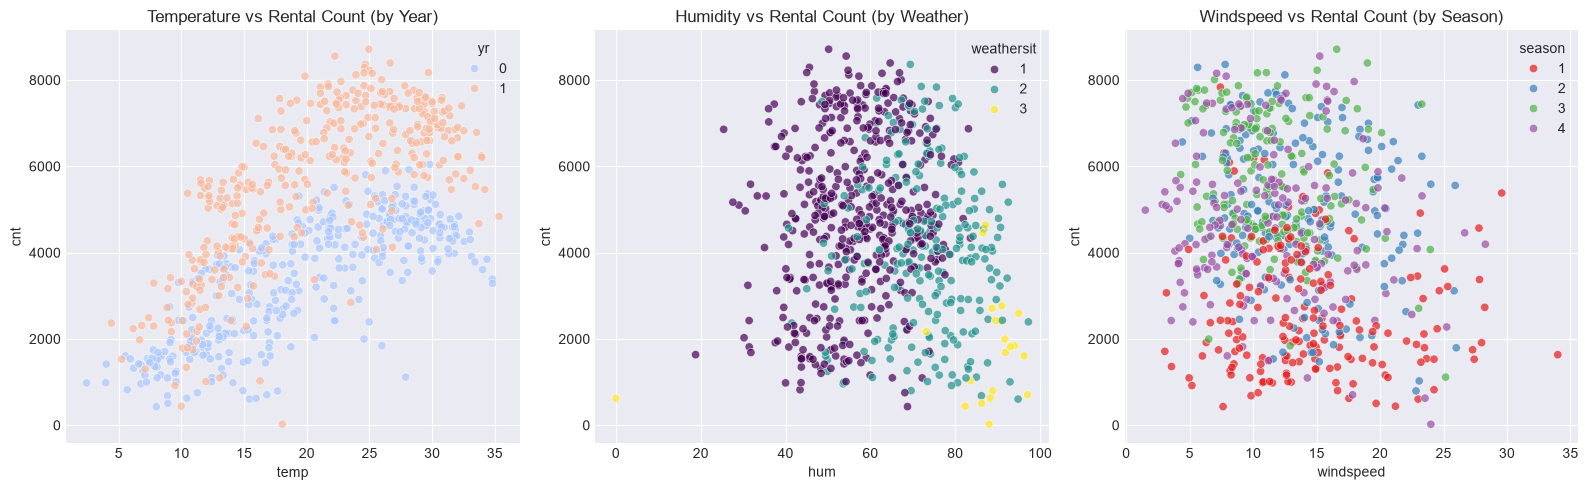

In [42]:
# 5. Scatter Plots for Feature Relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(x='temp', y='cnt', hue='yr', data=df, palette='coolwarm', alpha=0.7, ax=axes[0])
axes[0].set_title('Temperature vs Rental Count (by Year)')

sns.scatterplot(x='hum', y='cnt', hue='weathersit', data=df, palette='viridis', alpha=0.7, ax=axes[1])
axes[1].set_title('Humidity vs Rental Count (by Weather)')

sns.scatterplot(x='windspeed', y='cnt', hue='season', data=df, palette='Set1', alpha=0.7, ax=axes[2])
axes[2].set_title('Windspeed vs Rental Count (by Season)')

plt.tight_layout()
plt.savefig('eda_scatterplots.png', dpi=300)
plt.show()
plt.close()

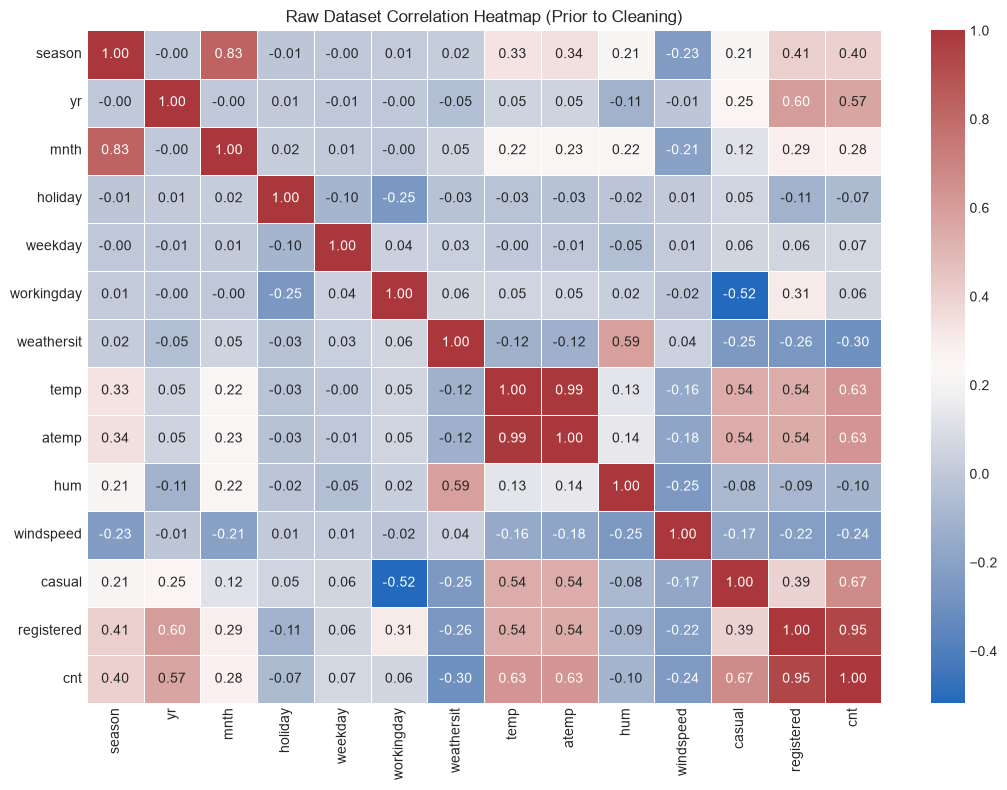

All EDA charts generated successfully.


In [43]:
# Create a correlation matrix for continuous variables
plt.figure(figsize=(11, 8))
raw_corr = df.drop(columns=['instant','dteday']).corr()

sns.heatmap(raw_corr, annot=True, fmt=".2f", cmap='vlag', linewidths=0.5, cbar=True)
plt.title('Raw Dataset Correlation Heatmap (Prior to Cleaning)')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=300)
plt.show()
plt.close()

print("All EDA charts generated successfully.")

In [44]:
# 1. Missing Values & Duplicates Check
missing_vals = df.isnull().sum().sum()
duplicates = df.duplicated().sum()

print(f"Missing values count: {missing_vals}")
print(f"Duplicates count: {duplicates}")

Missing values count: 0
Duplicates count: 0


In [45]:
# Inspect zero humidity outlier
zero_hum = df[df['hum'] == 0]
print("\nZero humidity row:")
print(zero_hum[['instant', 'dteday', 'season', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']])

# Clean zero humidity by replacing with median humidity of the corresponding month/season
# median_hum_m3 = df[df['mnth'] == 3]['hum'].median()
# df['hum'] = df['hum'].replace(0, median_hum_m3)

month_medians = (
    df.groupby("mnth")["hum"]
      .transform(lambda x: x[x > 0].median())
)

mask = df["hum"] == 0

df.loc[mask, "hum"] = month_medians[mask]


Zero humidity row:
    instant      dteday  season  weathersit       temp  hum  windspeed  cnt
68       69  10-03-2018       1           3  15.952731  0.0  17.545759  623


In [46]:
# 3.Catching Data Leakage, Dropping redundant/leakage columns


# Catching Data Leakage
# Verify the relationship
print((df['casual'] + df['registered'] == df['cnt']).all())

# Dropping redundant/leakage columns
cols_to_drop = ['instant', 'dteday', 'casual', 'registered', 'atemp']
df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned

True


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,14.110847,80.5833,10.749882,985
1,1,0,1,0,0,0,2,14.902598,69.6087,16.652113,801
2,1,0,1,0,1,1,1,8.050924,43.7273,16.636703,1349
3,1,0,1,0,2,1,1,8.200000,59.0435,10.739832,1562
4,1,0,1,0,3,1,1,9.305237,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...
725,1,1,12,0,4,1,2,10.420847,65.2917,23.458911,2114
726,1,1,12,0,5,1,2,10.386653,59.0000,10.416557,3095
727,1,1,12,0,6,0,2,10.386653,75.2917,8.333661,1341
728,1,1,12,0,0,0,1,10.489153,48.3333,23.500518,1796


In [47]:
# 3. Map categorical features to meaningful string names
season_map = {1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'}
weathersit_map = {1: 'clear', 2: 'mist_cloudy', 3: 'light_rain_snow', 4: 'heavy_rain_snow'}
mnth_map = {1: 'jan', 2: 'feb', 3: 'mar', 4: 'apr', 5: 'may', 6: 'jun', 
            7: 'jul', 8: 'aug', 9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'}
weekday_map = {0: 'sun', 1: 'mon', 2: 'tue', 3: 'wed', 4: 'thu', 5: 'fri', 6: 'sat'}

df_cleaned['season'] = df_cleaned['season'].map(season_map)
df_cleaned['weathersit'] = df_cleaned['weathersit'].map(weathersit_map)
df_cleaned['mnth'] = df_cleaned['mnth'].map(mnth_map)
df_cleaned['weekday'] = df_cleaned['weekday'].map(weekday_map)

print("\nShape before encoding:", df_cleaned.shape)
df_cleaned.head()


Shape before encoding: (730, 11)


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,spring,0,jan,0,sat,0,mist_cloudy,14.110847,80.5833,10.749882,985
1,spring,0,jan,0,sun,0,mist_cloudy,14.902598,69.6087,16.652113,801
2,spring,0,jan,0,mon,1,clear,8.050924,43.7273,16.636703,1349
3,spring,0,jan,0,tue,1,clear,8.200000,59.0435,10.739832,1562
4,spring,0,jan,0,wed,1,clear,9.305237,43.6957,12.522300,1600


In [48]:
df_cleaned.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,spring,0,jan,0,sat,0,mist_cloudy,14.110847,80.5833,10.749882,985
1,spring,0,jan,0,sun,0,mist_cloudy,14.902598,69.6087,16.652113,801
2,spring,0,jan,0,mon,1,clear,8.050924,43.7273,16.636703,1349
3,spring,0,jan,0,tue,1,clear,8.200000,59.0435,10.739832,1562
4,spring,0,jan,0,wed,1,clear,9.305237,43.6957,12.522300,1600


In [49]:
# 1. Load Cleaned Dataset (Prior to Encoding/Scaling)
# Assumes df_cleaned contains: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']

# Separate Predictors (X) and Target (y)
X = df_cleaned.drop(columns=['cnt'])
y = df_cleaned['cnt']

# 2. Define Feature Lists
num_features = ['temp', 'hum', 'windspeed']
cat_features = ['season', 'mnth', 'weathersit', 'weekday']
passthrough_features = ['yr','holiday', 'workingday']

# 3. Construct Pipelines and ColumnTransformer
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
        ('pass', 'passthrough', passthrough_features)
    ],
    verbose_feature_names_out=False
)

# 4. Perform Train-Test Split (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Fit & Transform Verification
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# Retrieve transformed feature names
feature_names = preprocessor.get_feature_names_out()

print(f"X_train original shape:    {X_train.shape}")
print(f"X_train transformed shape: {X_train_prepared.shape}")
print(f"Total Encoded Features:    {len(feature_names)}")
print(X_train.columns)

X_train original shape:    (584, 10)
X_train transformed shape: (584, 28)
Total Encoded Features:    28
Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'hum', 'windspeed'],
      dtype='str')


In [50]:


# Models dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0, max_iter=5000),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(C=1000, epsilon=10,kernel='rbf'),
    'Extra Trees (Optional 1)': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'AdaBoost (Optional 2)': AdaBoostRegressor(n_estimators=100, random_state=42)
}

results = []
training_times = {}
def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_test = len(y_test)

# Number of transformed features p
X_train_trans = preprocessor.fit_transform(X_train)
p = X_train_trans.shape[1]

fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    start_time = time.perf_counter()
    pipe.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time

    fitted_pipelines[name] = pipe
    training_times[name] = training_time
    
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_adj_r2 = adj_r2(test_r2, n_test, p)
    
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    
    results.append({
        'Model': name,
        "Training Time (s)": training_times[name],
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Adjusted R²': test_adj_r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape
    })

results_df = pd.DataFrame(results).sort_values(by='Test R²', ascending=False).reset_index(drop=True)
print(results_df.to_string())
results_df

                      Model  Training Time (s)  Train R²   Test R²  Adjusted R²         MAE            MSE        RMSE   MAPE (%)
0  Support Vector Regressor           0.062521  0.931545  0.926333     0.908703  374.022253  252150.230533  502.145627  10.847529
1             Random Forest           0.555179  0.980539  0.904973     0.882231  427.881370  325263.269395  570.318568  11.893838
2         Gradient Boosting           0.224960  0.954743  0.900708     0.876946  438.746005  339861.490684  582.976407  12.022965
3  Extra Trees (Optional 1)           0.561241  1.000000  0.898607     0.874342  415.233151  347051.982332  589.111180  11.704164
4          Ridge Regression           0.019116  0.843456  0.864325     0.831856  522.390596  464394.228237  681.464767  15.310383
5          Lasso Regression           0.022131  0.843532  0.863464     0.830788  523.516596  467342.731572  683.624701  15.385547
6         Linear Regression           0.027801  0.843655  0.862600     0.829717  522.97693

,Model,Training Time (s),Train R²,Test R²,Adjusted R²,MAE,MSE,RMSE,MAPE (%)
0,Support Vector Regressor,0.062521,0.931545,0.926333,0.908703,374.022253,252150.230533,502.145627,10.847529
1,Random Forest,0.555179,0.980539,0.904973,0.882231,427.881370,325263.269395,570.318568,11.893838
2,Gradient Boosting,0.224960,0.954743,0.900708,0.876946,438.746005,339861.490684,582.976407,12.022965
3,Extra Trees (Optional 1),0.561241,1.000000,0.898607,0.874342,415.233151,347051.982332,589.111180,11.704164
4,Ridge Regression,0.019116,0.843456,0.864325,0.831856,522.390596,464394.228237,681.464767,15.310383
5,Lasso Regression,0.022131,0.843532,0.863464,0.830788,523.516596,467342.731572,683.624701,15.385547
6,Linear Regression,0.027801,0.843655,0.862600,0.829717,522.976937,470299.749138,685.784040,15.436518
7,Decision Tree,0.028694,1.000000,0.856503,0.822161,491.438356,491168.561644,700.834190,13.735722
8,AdaBoost (Optional 2),0.370648,0.853621,0.829735,0.788988,602.957884,582790.847978,763.407393,15.942189


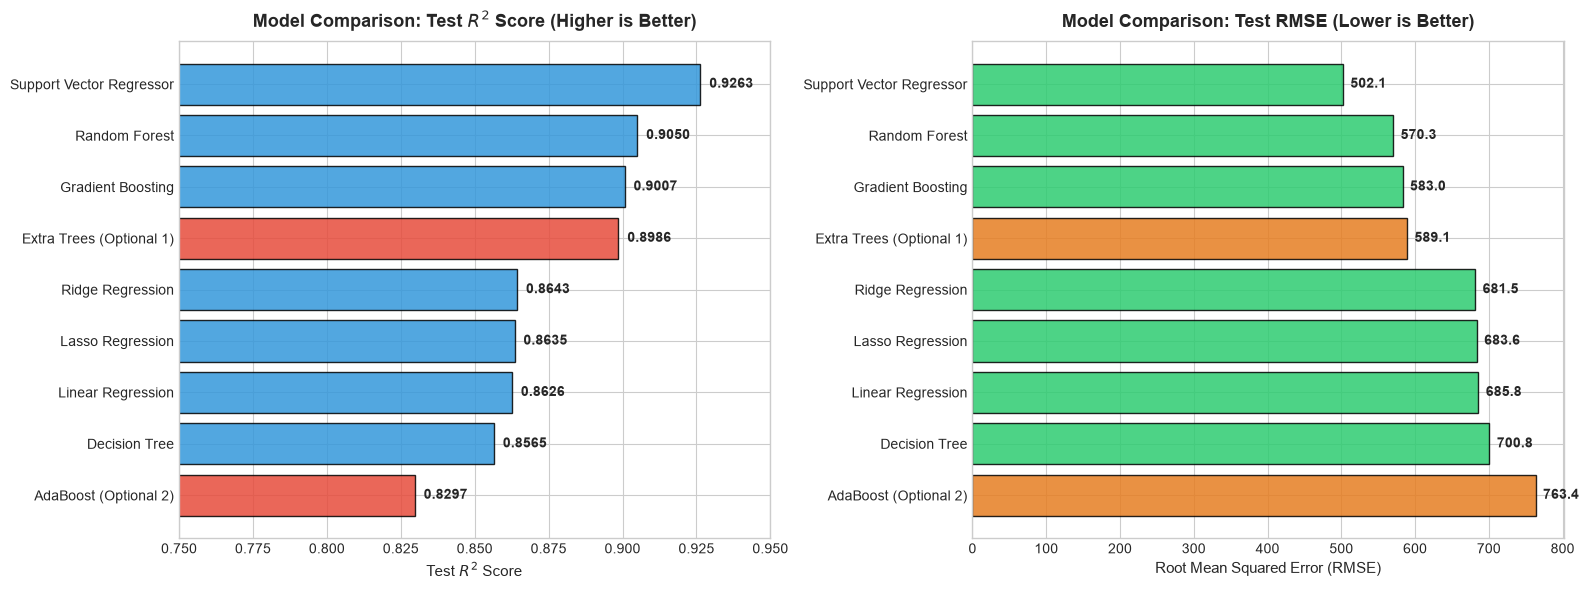

In [51]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort results for plotting
df_sorted_r2 = results_df.sort_values(by='Test R²', ascending=True)
df_sorted_rmse = results_df.sort_values(by='RMSE', ascending=False)

# Plot 1: Test R2 Comparison
colors_r2 = ['#3498db' if 'Optional' not in m else '#e74c3c' for m in df_sorted_r2['Model']]
axes[0].barh(df_sorted_r2['Model'], df_sorted_r2['Test R²'], color=colors_r2, edgecolor='black', alpha=0.85)
axes[0].set_title('Model Comparison: Test $R^2$ Score (Higher is Better)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Test $R^2$ Score', fontsize=11)
axes[0].set_xlim(0.75, 0.95)

for index, value in enumerate(df_sorted_r2['Test R²']):
    axes[0].text(value + 0.003, index, f"{value:.4f}", va='center', fontsize=10, fontweight='bold')

# Plot 2: Test RMSE Comparison
colors_rmse = ['#2ecc71' if 'Optional' not in m else '#e67e22' for m in df_sorted_rmse['Model']]
axes[1].barh(df_sorted_rmse['Model'], df_sorted_rmse['RMSE'], color=colors_rmse, edgecolor='black', alpha=0.85)
axes[1].set_title('Model Comparison: Test RMSE (Lower is Better)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Root Mean Squared Error (RMSE)', fontsize=11)

for index, value in enumerate(df_sorted_rmse['RMSE']):
    axes[1].text(value + 10, index, f"{value:.1f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()



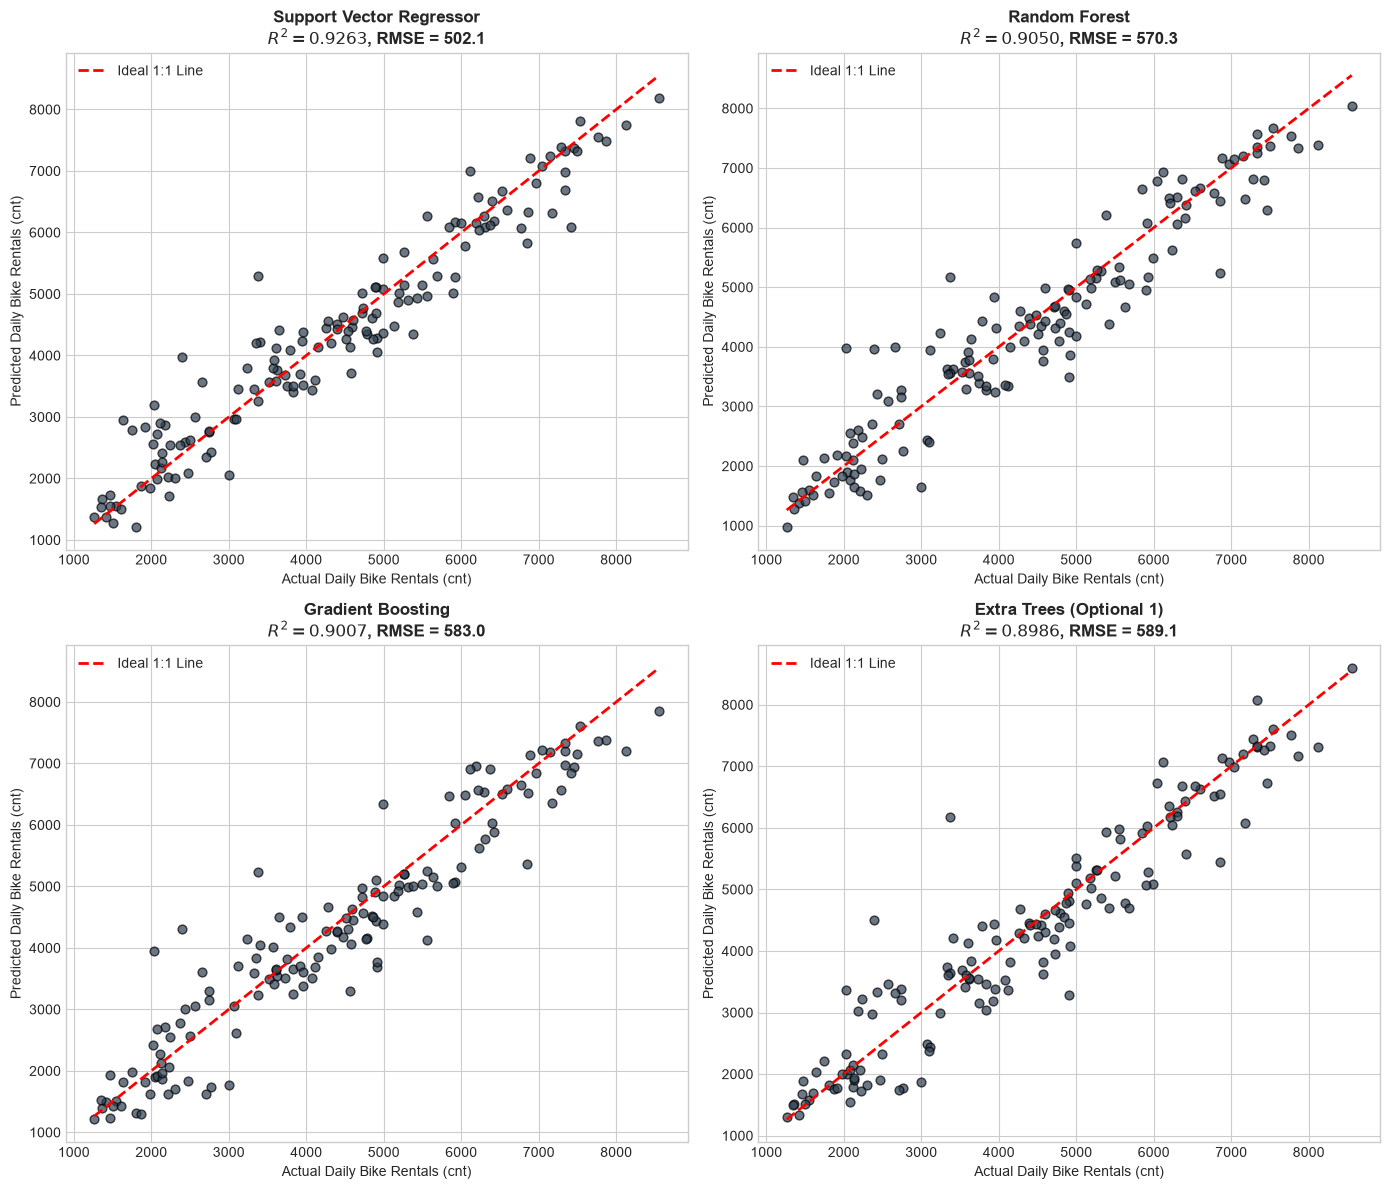

In [52]:
# Plot Actual vs Predicted for Top Models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

top_4_models = ['Support Vector Regressor', 'Random Forest', 'Gradient Boosting', 'Extra Trees (Optional 1)']

for i, model_name in enumerate(top_4_models):
    pipe = fitted_pipelines[model_name]
    y_pred = pipe.predict(X_test)
    
    axes[i].scatter(y_test, y_pred, alpha=0.7, color='#2c3e50', edgecolors='k', s=40)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1 Line')
    axes[i].set_title(f"{model_name}\n$R^2 = {results_df[results_df['Model']==model_name]['Test R²'].values[0]:.4f}$, RMSE = {results_df[results_df['Model']==model_name]['RMSE'].values[0]:.1f}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Actual Daily Bike Rentals (cnt)', fontsize=10)
    axes[i].set_ylabel('Predicted Daily Bike Rentals (cnt)', fontsize=10)
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

In [53]:
# 1. Extract the best model based on highest Test R² score
best_row = results_df.sort_values(by='Test R²', ascending=False).iloc[0]
best_model_name = best_row['Model']

# 2. Print summary report to the console
print("=" * 55)
print("             BEST PERFORMING MODEL REPORT             ")
print("=" * 55)
print(f" Top Performing Model : {best_model_name}")
print(f" Test R² Score        : {best_row['Test R²']:.4f}")
print(f" Adjusted R² Score    : {best_row['Adjusted R²']:.4f}")
print(f" Test RMSE            : {best_row['RMSE']:.2f} rentals")
print(f" Test MAE             : {best_row['MAE']:.2f} rentals")
print(f" Test MAPE            : {best_row['MAPE (%)']:.2f}%")
print("=" * 55)

# 3. Export the winning model pipeline to .pkl
best_pipeline = fitted_pipelines[best_model_name]
pkl_filename = 'best_bike_sharing_model.pkl'

import joblib
joblib.dump(best_pipeline, pkl_filename)
print(f"\n [SUCCESS] Exported '{best_model_name}' pipeline to '{pkl_filename}'")

             BEST PERFORMING MODEL REPORT             
 Top Performing Model : Support Vector Regressor
 Test R² Score        : 0.9263
 Adjusted R² Score    : 0.9087
 Test RMSE            : 502.15 rentals
 Test MAE             : 374.02 rentals
 Test MAPE            : 10.85%

 [SUCCESS] Exported 'Support Vector Regressor' pipeline to 'best_bike_sharing_model.pkl'


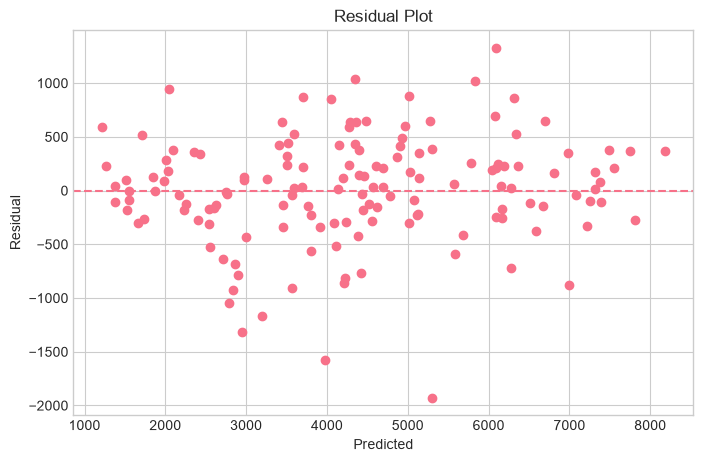

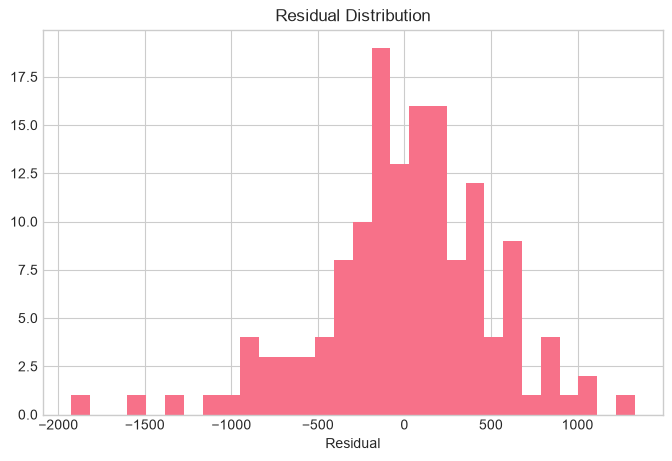

In [54]:

predictions = best_pipeline.predict(X_test)
residuals = y_test - predictions

plt.figure(figsize=(8,5))
plt.scatter(predictions, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()